# Projet clear road

Ce projet vise à développer un modèle de machine learning capable de prédire le volume de trafic routier dans un contexte de Smart City, à partir de données météorologiques et temporelles.

L’objectif est de comprendre les principaux facteurs influençant la circulation et de construire un système de prédiction performant et interprétable.

**Données utilisées**

Le dataset contient des variables :

🌡️ Météo : température, pluie, neige, couverture nuageuse, type de temps
⏰ Temps : heure, jour de la semaine, mois, week-end, jour férié
🚦 Cible : volume de trafic (traffic_volume)

## Import

In [1]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import joblib
import streamlit as st

## Loard Data

In [3]:
df = pd.read_csv("/kaggle/input/datasets/alimisara/trafic-horaire/Metro_Interstate_Traffic_Volume.csv" )

## EDA

### Graphics and options

In [4]:
sns.set()

In [5]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [6]:
df.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


In [7]:
df.sample(20)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
46779,NaN,298.550,0.00,0.0,90,Clouds,overcast clouds,2018-08-17 12:00:00,5076
7582,NaN,301.250,0.00,0.0,64,Rain,moderate rain,2013-07-10 19:00:00,3523
8805,NaN,305.150,0.00,0.0,1,Clear,sky is clear,2013-09-06 14:00:00,5770
24682,NaN,292.860,0.00,0.0,40,Drizzle,light intensity drizzle,2016-07-05 04:00:00,729
3903,NaN,268.310,0.00,0.0,90,Haze,haze,2013-02-26 02:00:00,229
23311,NaN,279.160,0.76,0.0,90,Rain,moderate rain,2016-05-13 07:00:00,6102
37362,NaN,296.460,0.00,0.0,90,Mist,mist,2017-09-22 09:00:00,4910
16036,NaN,288.650,0.00,0.0,1,Clear,sky is clear,2015-06-27 02:00:00,672
26140,NaN,293.830,0.00,0.0,1,Mist,mist,2016-08-29 05:00:00,2842
16401,NaN,293.730,0.00,0.0,1,Clear,sky is clear,2015-07-08 20:00:00,3090


### Structure

In [8]:
df.shape

(48204, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [10]:
df.nunique()

holiday                   11
temp                    5843
rain_1h                  372
snow_1h                   12
clouds_all                60
weather_main              11
weather_description       38
date_time              40575
traffic_volume          6704
dtype: int64

In [11]:
df['date_time'].duplicated().sum()

np.int64(7629)

In [12]:
df[df['date_time'].duplicated(keep=False)].sort_values('date_time')

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
178,NaN,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793
179,NaN,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793
180,NaN,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283
181,NaN,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283
182,NaN,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680
...,...,...,...,...,...,...,...,...,...
48173,NaN,280.68,0.0,0.0,90,Clouds,overcast clouds,2018-09-29 19:00:00,3818
48192,NaN,283.48,0.0,0.0,90,Rain,light rain,2018-09-30 14:00:00,4380
48193,NaN,283.48,0.0,0.0,90,Drizzle,light intensity drizzle,2018-09-30 14:00:00,4380
48194,NaN,283.84,0.0,0.0,75,Rain,proximity shower rain,2018-09-30 15:00:00,4302


In [13]:
df.duplicated().sum()

np.int64(17)

In [14]:
df.isna().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

<Axes: >

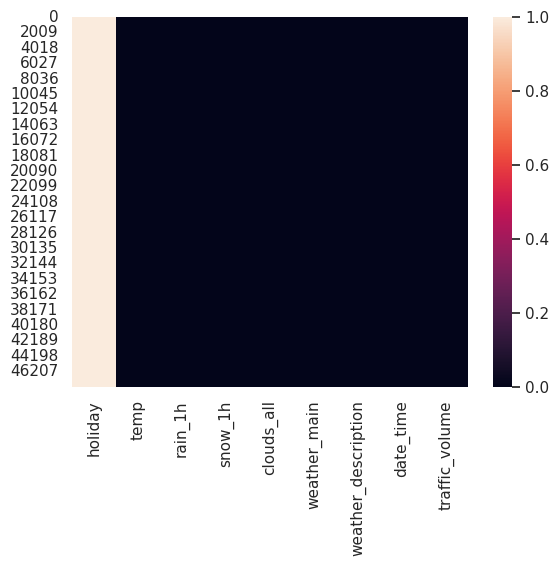

In [15]:
# graphique des données manquantes
sns.heatmap(df.isna())

La seule feature qui présente des données manquantes est 'holiday'. Ce ne sont pas en réalité des données manquantes mais des jours non fériés.

In [16]:
df.describe(include = np.number)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [17]:
df.describe(include=object)

,holiday,weather_main,weather_description,date_time
count,61,48204,48204,48204
unique,11,11,38,40575
top,Labor Day,Clouds,sky is clear,2013-04-18 22:00:00
freq,7,15164,11665,6


In [18]:
df[df['holiday'].notna()].head(10)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
126,Columbus Day,273.08,0.0,0.0,20,Clouds,few clouds,2012-10-08 00:00:00,455
1123,Veterans Day,288.12,0.0,0.0,87,Clear,sky is clear,2012-11-12 00:00:00,1000
1370,Thanksgiving Day,278.54,0.0,0.0,20,Mist,mist,2012-11-22 00:00:00,919
2360,Christmas Day,264.40,0.0,0.0,90,Clouds,overcast clouds,2012-12-25 00:00:00,803
2559,New Years Day,263.49,0.0,0.0,58,Clouds,broken clouds,2013-01-01 00:00:00,1439
3697,Washingtons Birthday,258.96,0.0,0.0,20,Clouds,few clouds,2013-02-18 00:00:00,556
6430,Memorial Day,286.37,0.0,0.0,90,Clouds,overcast clouds,2013-05-27 00:00:00,863
7414,Independence Day,290.08,0.0,0.0,1,Clear,sky is clear,2013-07-04 00:00:00,1060
8575,State Fair,297.42,0.0,0.0,12,Clouds,few clouds,2013-08-22 00:00:00,661
8742,Labor Day,288.78,0.0,0.0,0,Clear,Sky is Clear,2013-09-02 00:00:00,1041


## Data Cleaning

In [19]:
def data_cleaning(df):
    # suppresion des données duplicatées
    df = df.drop_duplicates(subset='date_time')
    # suppression de la variable "weather_description" 
    df = df.drop("weather_description", axis = 1)
    # suppression des valeurs aberrantes de "rain_1h"
    df = df[df['rain_1h'] < 500]
    # suppression des valeurs aberrantes de "temp"
    df = df[df['temp'] > 200]
    return df
    

In [20]:
df = data_cleaning(df)

In [21]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918


In [22]:
df.shape

(40564, 8)

In [23]:
df.describe(include = np.number)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,40564.000000,40564.000000,40564.000000,40564.000000,40564.000000
mean,281.385602,0.076353,0.000117,44.209299,3291.081402
std,13.092942,0.769729,0.005677,38.682163,1984.638849
min,243.390000,0.000000,0.000000,0.000000,0.000000
25%,271.850000,0.000000,0.000000,1.000000,1249.750000
50%,282.867500,0.000000,0.000000,40.000000,3429.000000
75%,292.280000,0.000000,0.000000,90.000000,4952.000000
max,310.070000,55.630000,0.510000,100.000000,7280.000000


In [24]:
df['date_time'].duplicated().sum()

np.int64(0)

## Feature Engineering

In [25]:
def feature_eng(df):
    # recuperation des heures, jours à partir de date_time
    df['date_time'] = pd.to_datetime(df['date_time'])
    # les heures
    df['hour'] = df['date_time'].dt.hour
    # les mois
    df['month'] = df['date_time'].dt.month
    # les jours de semaines
    df['dayofweek'] = df['date_time'].dt.dayofweek
    # les jours de weekend
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

    # Transformation de holiday en une variable binaire
    df['is_holiday'] = df['holiday'].notna().astype(int)
    # suppression des variables 'date_time' et 'holiday'
    df = df.drop(columns=['holiday', 'date_time'])
    
    return df

In [26]:
df = feature_eng(df)

In [27]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,month,dayofweek,is_weekend,is_holiday
0,288.28,0.0,0.0,40,Clouds,5545,9,10,1,0,0
1,289.36,0.0,0.0,75,Clouds,4516,10,10,1,0,0
2,289.58,0.0,0.0,90,Clouds,4767,11,10,1,0,0
3,290.13,0.0,0.0,90,Clouds,5026,12,10,1,0,0
4,291.14,0.0,0.0,75,Clouds,4918,13,10,1,0,0


In [28]:
df.tail()

,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,month,dayofweek,is_weekend,is_holiday
48199,283.45,0.0,0.0,75,Clouds,3543,19,9,6,1,0
48200,282.76,0.0,0.0,90,Clouds,2781,20,9,6,1,0
48201,282.73,0.0,0.0,90,Thunderstorm,2159,21,9,6,1,0
48202,282.09,0.0,0.0,90,Clouds,1450,22,9,6,1,0
48203,282.12,0.0,0.0,90,Clouds,954,23,9,6,1,0


In [29]:
df.sample(10)

,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,month,dayofweek,is_weekend,is_holiday
39462,284.72,0.0,0.0,90,Mist,4641,11,12,0,0,0
36534,284.58,0.0,0.0,5,Clear,6452,7,8,2,0,0
18327,296.04,2.1,0.0,90,Rain,2903,5,9,3,0,0
3832,270.30,0.0,0.0,90,Snow,4492,15,2,5,1,0
12645,248.88,0.0,0.0,1,Clear,359,3,3,0,0,0
46384,290.35,0.0,0.0,75,Thunderstorm,5213,8,8,4,0,0
26706,285.37,0.0,0.0,1,Clear,1794,7,9,6,1,0
39000,272.72,0.0,0.0,90,Clouds,5315,14,11,3,0,0
41342,255.95,0.0,0.0,1,Snow,2830,5,2,3,0,0
42666,274.08,0.0,0.0,90,Drizzle,516,0,3,1,0,0


### Analyse de la target

<Axes: >

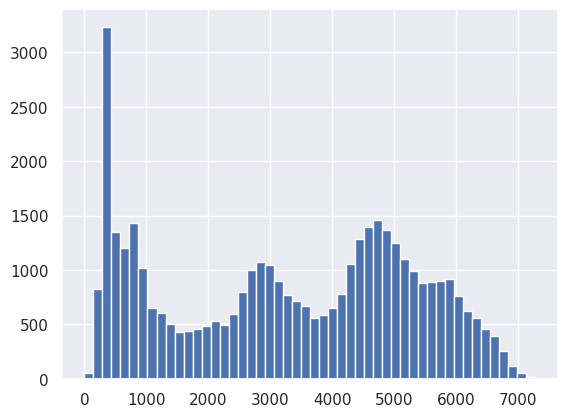

In [30]:
df['traffic_volume'].hist(bins=50)

In [31]:
df.groupby('hour')['traffic_volume'].mean()

hour
0      844.854324
1      521.318713
2      392.637006
3      373.266947
4      701.543798
5     2104.389780
6     4173.518739
7     4772.110114
8     4595.331754
9     4394.778523
10    4204.876833
11    4498.458908
12    4739.118794
13    4741.578004
14    4957.022982
15    5271.737823
16    5708.614528
17    5350.719784
18    4306.467301
19    3311.021390
20    2869.703920
21    2699.360915
22    2224.418848
23    1490.710345
Name: traffic_volume, dtype: float64

In [32]:
df.groupby('weather_main')['traffic_volume'].mean().sort_values()

weather_main
Squall           420.000000
Smoke           2559.666667
Fog             2724.442786
Mist            2854.214076
Thunderstorm    2993.366446
Snow            3001.861123
Clear           3056.555331
Drizzle         3159.821359
Rain            3354.813129
Haze            3597.939948
Clouds          3616.988230
Name: traffic_volume, dtype: float64

In [33]:
df.groupby('is_weekend')['traffic_volume'].mean()

is_weekend
0    3557.559536
1    2624.909060
Name: traffic_volume, dtype: float64

### Encodage de la variable weather_main

In [34]:
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

In [35]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,month,dayofweek,is_weekend,is_holiday,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,5545,9,10,1,0,0,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,4516,10,10,1,0,0,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,4767,11,10,1,0,0,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,5026,12,10,1,0,0,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,4918,13,10,1,0,0,True,False,False,False,False,False,False,False,False,False


## Séparation

In [36]:
int(len(df)*0.8)

32451

In [37]:
# séparation train-test chronologique
train_size = int(len(df)*0.8) # la taille des données de train
train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [38]:
print(train.shape, test.shape)

(32451, 20) (8113, 20)


In [39]:
X_train = train.drop('traffic_volume', axis=1)
y_train = train['traffic_volume']

X_test = test.drop('traffic_volume', axis=1)
y_test = test['traffic_volume']

In [40]:
print(X_train.shape, X_test.shape)

(32451, 19) (8113, 19)


## Base Modele

In [41]:
# linear regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Evaluation of base model with TimeSeriesSplit

In [42]:
tscv = TimeSeriesSplit(n_splits=5)

mae_list = []
rmse_list = []
for train_index, val_index in tscv.split(X_train):
    
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_val)
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    mae_list.append(mae)
    rmse_list.append(rmse)

print("MAE moyen :", np.mean(mae_list))
print("RMSE moyen :", np.mean(rmse_list))

MAE moyen : 1561.4822686882576
RMSE moyen : 1782.2922103391327


Un modèle de régression linéaire a été testé comme baseline, on obtient une métrique mae de 1561 et une rmse de 1782 qui sont trop élevée.

## RandomForest Model

In [43]:
tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

for train_index, val_index in tscv.split(X_train):
    
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)

print("MAE moyen :", np.mean(mae_scores))
print("RMSE moyen :", np.mean(rmse_scores))

MAE moyen : 287.90822856837093
RMSE moyen : 496.3118622946189


Le modèle RandomForest a permis de réduire significativement l’erreur de prédiction par rapport à la régression linéaire, ce qui justifie la présence de relations non linéaires dans les données de trafic.

## Evaluation du model avec les données test

In [44]:
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

In [45]:
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("MAE test :", mae_test)
print("RMSE test :", rmse_test)

MAE test : 266.59493763842636
RMSE test : 478.25477746460035


Le modèle RandomForest a montré une excellente capacité de généralisation, avec une erreur moyenne d’environ 8% (une erreur de 266 trafic sur 3300 en moyenne) sur les données de test, confirmant la pertinence des variables explicatives utilisées.

### Importance des features

In [46]:
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False)

hour                         8.745022e-01
dayofweek                    5.714068e-02
is_weekend                   5.120216e-02
temp                         9.532886e-03
month                        3.861080e-03
clouds_all                   1.092339e-03
rain_1h                      1.068039e-03
weather_main_Snow            3.933405e-04
weather_main_Mist            3.739917e-04
weather_main_Clouds          2.951934e-04
weather_main_Haze            1.942040e-04
weather_main_Thunderstorm    1.364757e-04
weather_main_Rain            1.048965e-04
snow_1h                      6.427766e-05
is_holiday                   1.759489e-05
weather_main_Drizzle         1.313462e-05
weather_main_Fog             7.392247e-06
weather_main_Squall          1.108194e-07
weather_main_Smoke           4.958686e-08
dtype: float64

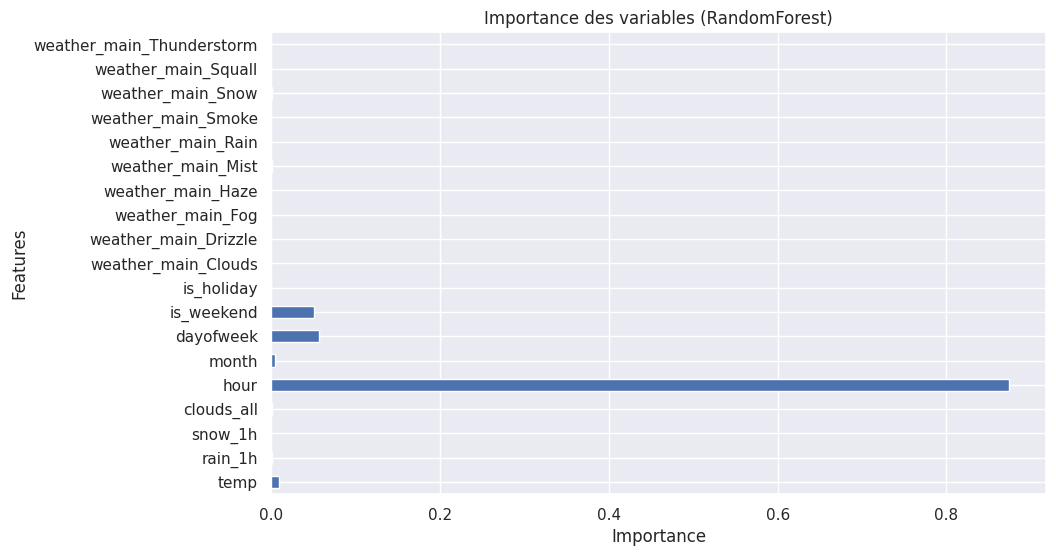

In [47]:
plt.figure(figsize=(10,6))

feature_importance.plot(kind='barh')

plt.title("Importance des variables (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

## Visualisation Streamlit

In [48]:
# l'ordre des features de X_tran
X_train.columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'month',
       'dayofweek', 'is_weekend', 'is_holiday', 'weather_main_Clouds',
       'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze',
       'weather_main_Mist', 'weather_main_Rain', 'weather_main_Smoke',
       'weather_main_Snow', 'weather_main_Squall',
       'weather_main_Thunderstorm'],
      dtype='object')

In [49]:
# Sauvegarde du modèle
joblib.dump(model, "traffic_model.pkl")

['traffic_model.pkl']

In [50]:
# =========================
# LOAD MODEL
# =========================
model = joblib.load("traffic_model.pkl")

st.title("Prédiction du trafic (Smart City)")
st.write("Application de prédiction du trafic routier en temps réel")

# =========================
# INPUTS
# =========================
hour = st.slider("Heure", 0, 23, 12)
month = st.slider("Mois", 1, 12, 6)
dayofweek = st.slider("Jour de la semaine (0=Lundi)", 0, 6, 2)

is_weekend = 1 if dayofweek in [5, 6] else 0
is_holiday = st.selectbox("Jour férié ?", [0, 1])

temp = st.number_input("Température (K)", value=290.0)
rain_1h = st.number_input("Pluie (mm)", value=0.0)
snow_1h = st.number_input("Neige", value=0.0)
clouds_all = st.slider("Nuages (%)", 0, 100, 50)

weather = st.selectbox("Météo", [
    "Clouds", "Drizzle", "Fog", "Haze", "Mist",
    "Rain", "Smoke", "Snow", "Squall", "Thunderstorm"
])

# =========================
# ENCODING WEATHER
# =========================
weather_cols = [
    'weather_main_Clouds', 'weather_main_Drizzle', 'weather_main_Fog',
    'weather_main_Haze', 'weather_main_Mist', 'weather_main_Rain',
    'weather_main_Smoke', 'weather_main_Snow', 'weather_main_Squall',
    'weather_main_Thunderstorm'
]

weather_values = [1 if weather == col.split('_')[-1] else 0 for col in weather_cols]

# =========================
# FINAL INPUT (EXACT ORDER X_train)
# =========================
input_data = np.array([[
    temp,
    rain_1h,
    snow_1h,
    clouds_all,
    hour,
    month,
    dayofweek,
    is_weekend,
    is_holiday,
    *weather_values
]])

# =========================
# PREDICTION
# =========================
if st.button("Prédire le trafic"):

    prediction = model.predict(input_data)[0]

    st.success(f" Trafic estimé : {int(prediction)} véhicules")

    # =========================
    # GRAPH 1: TRAFFIC LEVEL
    # =========================
    st.subheader(" Niveau de trafic")

    categories = ["Faible", "Moyen", "Élevé"]
    level = [0, 0, 0]

    if prediction < 2000:
        level = [1, 0, 0]
    elif prediction < 4500:
        level = [0, 1, 0]
    else:
        level = [0, 0, 1]

    fig, ax = plt.subplots()
    ax.bar(categories, level)
    ax.set_ylabel("Niveau")
    ax.set_title("Classification du trafic")

    st.pyplot(fig)

    # =========================
    # GRAPH 2: HOURLY IMPACT
    # =========================
    st.subheader("Impact de l'heure sur le trafic")

    hours = list(range(24))
    predictions_hour = []

    for h in hours:
        temp_input = input_data.copy()
        temp_input[0][4] = h  # modifier hour

        pred = model.predict(temp_input)[0]
        predictions_hour.append(pred)

    fig2, ax2 = plt.subplots()
    ax2.plot(hours, predictions_hour)
    ax2.set_xlabel("Heure")
    ax2.set_ylabel("Trafic")
    ax2.set_title("Variation du trafic selon l'heure")

    st.pyplot(fig2)

2026-04-13 18:26:32.624 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 18:26:32.885 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-13 18:26:32.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 18:26:32.887 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 18:26:32.888 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 18:26:32.889 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 18:26:32.890 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 18:26:32.891 Thread 'MainThread': mi

Dans un terminal avec vscode, l'app s'excute 